# T45 — Paleo-prospectivity of porphyry Cu-Au in the SW-Pacific arc system

**Adapted from Farahbakhsh et al. (2025) STAMP_PNG. Reconstruct the published porphyry Cu-Au deposits of New Guinea + the Solomon Islands to their mineralisation ages, overlay the contemporaneous Zahirovic 2022 subduction geometry, and render the result as a paleo-Earth map that shows where in the deep past the SW-Pacific arc system was generating economic mineralisation.**

## What this notebook produces

Porphyry Cu-Au deposits form above active subduction zones in distinctive arc-tectonic settings. Their present-day distribution mostly reflects the *cumulative* arc history, not the configuration at any one age — a deposit visible in PNG today may have been generated above a subduction zone that no longer exists, beneath a microcontinent that has since accreted.

This notebook reconstructs every published SW-Pacific porphyry Cu-Au deposit to its individual mineralisation age (1–35 Ma depending on the deposit) under Zahirovic 2022 and renders the result on top of the contemporaneous topology. The figure makes the alignment between deposit location and active subduction zone explicit in paleo-coordinates — the basic visual prerequisite for any reconstruction-driven prospectivity study.

A second cell extends the analysis with the simplest possible prospectivity score: distance from each deposit's reconstructed paleo-position to the nearest contemporaneous subduction trench. The histogram of these distances bounds the "porphyry-generating" distance window for the SW-Pacific arc.

**Audience**: postgrad.
**Difficulty**: ★★★.

## Learning objectives

- Reconstruct a set of ore-deposit locations to age-of-mineralisation paleo-positions with `gplately`.
- Overlay reconstructed deposits on contemporaneous subduction-zone geometry from a topological plate model.
- Compute a deposit-to-trench distance metric in paleo-coordinates as a first-order prospectivity score.

## Prerequisites and runtime

- Plate model: Zahirovic 2022.
- Bundled data: `data/mineral_exploration/sw_pacific_porphyries.csv` — tutorial-scale subset of the Farahbakhsh et al. (2025) compilation (~50 deposits, lon / lat / mineralisation age in Ma / commodity / size).
- Python: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`.
- Runtime: ~1 minute.

## Data availability

This notebook reads the bundled SW-Pacific porphyry compilation at `data/mineral_exploration/sw_pacific_porphyries.csv`. The full compilation underlying Farahbakhsh et al. (2025) is hosted in:

> Farahbakhsh, E., Zahirovic, S., McInnes, B. I. A., et al. (2025). Spatio-temporal machine-learning prospectivity for porphyry Cu-Au deposits in the SW Pacific arc system. *Tectonics* 44, e2024TC008362. https://doi.org/10.1029/2024TC008362
> Repo: https://github.com/EarthByte/STAMP_PNG

The repo includes the full deposit database, the spatio-temporal feature stack used by the ML classifier, and the trained model. For production work clone that repo and point the `DEPOSITS_CSV` configuration variable below at the full compilation.

In [7]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import os, numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

In [8]:
# === USER CONFIGURATION =====================================================
MODEL_NAME    = "Zahirovic2022"
DEPOSITS_CSV  = "data/mineral_exploration/sw_pacific_porphyries.csv"
TARGET_TIME   = 10.0   # Ma — common Miocene snapshot for SW-Pacific porphyries
REGION        = [125, 165, -20, 5]   # (W, E, S, N) — New Guinea + Solomons
# ============================================================================


## 1. Load the deposit compilation

In [9]:
# Cell 2 — load
dep = pd.read_csv(DEPOSITS_CSV, comment="#")
print(f"  loaded {len(dep)} deposits, ages {dep['age_ma'].min():.0f}–{dep['age_ma'].max():.0f} Ma")
dep.head()


  loaded 50 deposits, ages 0–35 Ma


,name,lon,lat,age_ma,commodity,size
0,Grasberg,137.1,-4.06,3.5,Cu-Au,supergiant
1,Ok Tedi,141.1,-5.20,1.2,Cu-Au,giant
2,Frieda River,141.9,-4.92,13.0,Cu-Au,large
3,Wafi-Golpu,146.5,-7.40,5.0,Cu-Au,large
4,Panguna,155.4,-6.32,5.5,Cu-Au,giant


## 2. Reconstruct each deposit to its own mineralisation age

In [10]:
# Cell 3 — per-deposit paleo-positions
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

paleo_lons, paleo_lats = [], []
for _, row in dep.iterrows():
    pt = gplately.Points(recon, [row["lon"]], [row["lat"]])
    rlon, rlat = pt.reconstruct(float(row["age_ma"]), return_array=True)
    paleo_lons.append(float(rlon[0])); paleo_lats.append(float(rlat[0]))
dep["paleo_lon"] = paleo_lons
dep["paleo_lat"] = paleo_lats


## 3. Paleo-Earth map at TARGET_TIME with deposits coloured by age

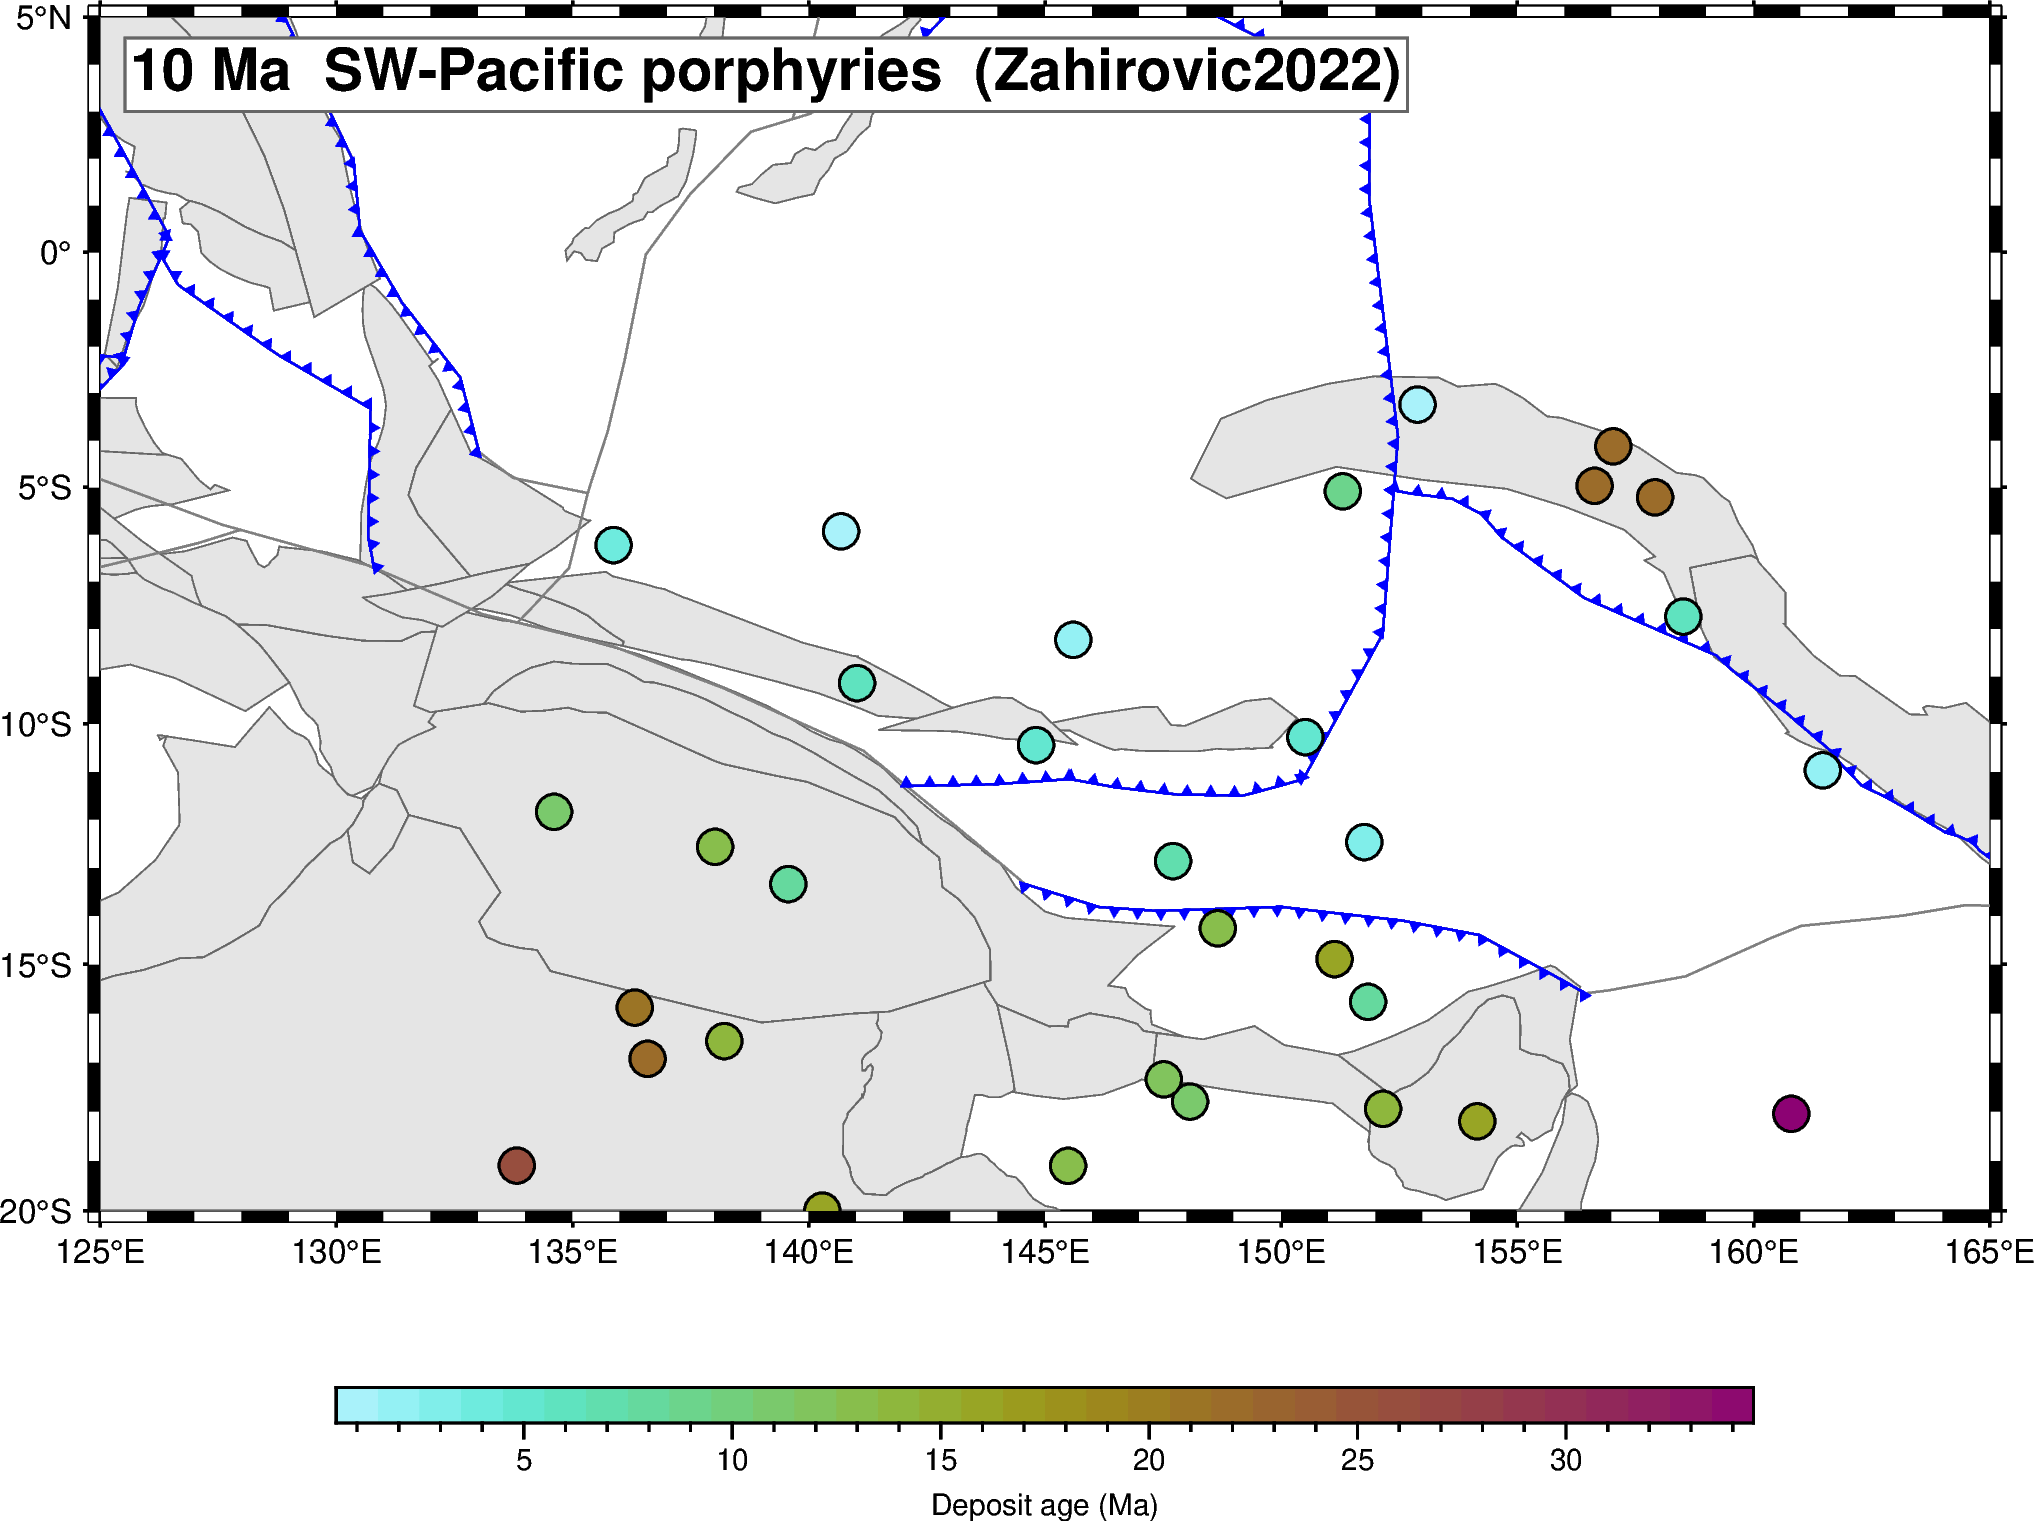

In [11]:
# Cell 4 — render
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(TARGET_TIME))
engine = gplately.PygmtPlotEngine()

fig = pygmt.Figure()
fig.basemap(region=REGION, projection="M16c", frame=["af"])
engine.plot_geo_data_frame(fig, gplot.get_continents(),
                           fill="gray90", pen="0.3p,gray40")
engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                           pen="0.5p,gray50")
(_tl, _tr) = gplot.get_subduction_direction()
engine.plot_subduction_zones(fig, _tl, _tr, color="blue")

pygmt.makecpt(cmap="hawaii",
              series=[dep["age_ma"].min(), dep["age_ma"].max(), 1],
              reverse=True)
fig.plot(x=dep["paleo_lon"], y=dep["paleo_lat"],
         style="c0.30c", fill=dep["age_ma"], cmap=True,
         pen="0.6p,black")
fig.colorbar(frame="af+lDeposit age (Ma)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
fig.text(text=f"{TARGET_TIME:.0f} Ma  SW-Pacific porphyries  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))


## 4. Deposit-to-trench distance — first-order prospectivity score

In [12]:
# Cell 5 — distance to nearest trench
def trench_distance_km(plon, plat, t):
    """Great-circle distance from (plon, plat) to the nearest contemporaneous
    subduction-zone segment in km."""
    gplot.time = float(t)
    trenches = gplot.get_trenches()
    if trenches is None or len(trenches) == 0:
        return np.nan
    pt = pygplates.PointOnSphere(plat, plon)
    best = np.inf
    for geom in trenches.geometry:
        if geom is None: continue
        parts = geom.geoms if hasattr(geom, "geoms") else [geom]
        for part in parts:
            for x, y in part.coords:
                d = pygplates.GeometryOnSphere.distance(
                    pt, pygplates.PointOnSphere(y, x)) * 6371.0
                if d < best: best = d
    return best

dep["trench_dist_km"] = [
    trench_distance_km(row["paleo_lon"], row["paleo_lat"], row["age_ma"])
    for _, row in dep.iterrows()
]
print(f"  median deposit-to-trench distance: {dep['trench_dist_km'].median():.0f} km")
print(f"  90 %-ile: {dep['trench_dist_km'].quantile(0.9):.0f} km")


  median deposit-to-trench distance: 335 km
  90 %-ile: 916 km


## Extend this

- **Spatio-temporal ML.** This notebook computes one prospectivity feature (deposit-to-trench distance). Farahbakhsh et al. (2025) train a classifier on a feature stack including convergence rate, slab dip, sediment thickness, and subduction obliquity. The full pipeline is in the upstream `STAMP_PNG` repo.
- **Different commodity.** Filter to `commodity == "Au"` or `commodity == "Mo"` and re-run. The reconstructed-distance distribution shifts.
- **Cross-reference T13.** T13 maps paleo-σHmax along subduction zones; T45 maps paleo-deposits along subduction zones. Overlay both for a single age and look for systematic alignment between σHmax orientation and the porphyry-generating front.

## References

- Farahbakhsh, E. et al. (2025). Spatio-temporal machine-learning prospectivity for porphyry Cu-Au deposits in the SW Pacific arc system. *Tectonics* 44, e2024TC008362.
- Zahirovic, S. et al. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal*.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
- Butterworth, N., Steinberg, D., Müller, R.D., Williams, S., Merdith, A.S. & Hardy, S. (2021). Tectonic environments of South American porphyry copper magmatism through time revealed by spatiotemporal data mining. *Tectonics* 40, e2020TC006273. https://doi.org/10.1029/2020TC006273
- Sillitoe, R.H. (2010). Porphyry copper systems. *Economic Geology* 105(1), 3–41. https://doi.org/10.2113/gsecongeo.105.1.3
